# HP 8563E Spectrum Analyzer — GPIB Control

**Instrument:** HP / Agilent 8563E Spectrum Analyzer (9 kHz – 26.5 GHz)  
**Interface:** GPIB-USB Adapter (NI GPIB-USB-HS or equivalent)  
**Command set:** HP proprietary (not SCPI)

---
**How to use:**
1. Edit the **Configuration Block** (Cell 2) for your GPIB address and sweep parameters.
2. Run Cell 3 (imports & connection) once per session.
3. Run the function definition cell (Cell 4).
4. Use the example cells or call functions directly.

## ⚙️ CONFIGURATION BLOCK — Edit All Parameters Here

In [19]:
# ============================================================
#  GPIB CONNECTION
# ============================================================
GPIB_ADDR_HP8563E  = 18     # GPIB address (check rear-panel label, default 18)
GPIB_BOARD_INDEX   = 0      # USB-GPIB adapter index (0 = first/only adapter)

# ============================================================
#  SWEEP PARAMETERS
# ============================================================
SA_CENTER_FREQ_HZ  = 100e6    # Center frequency Hz      (9e3 – 26.5e9)
SA_SPAN_HZ         = 200  # Span Hz                  (0 = zero-span)
SA_REF_LEVEL_DBM   = 0.0    # Reference level dBm      (–80 to +30)
SA_RBW_HZ          = 1    # Resolution bandwidth Hz
SA_VBW_HZ          = 1e6    # Video bandwidth Hz
SA_ATTENUATION_DB  = 10     # Input attenuation dB     (0–70, multiples of 10)
SA_SWEEP_TIME_S    = 0      # Sweep time sec           (0 = auto)

# ============================================================
#  TRACE & MARKER
# ============================================================
SA_TRACE           = 'TRA'  # Active trace: 'TRA', 'TRB', or 'TRC'
SA_DETECTOR        = 'POS'  # Detector: 'POS', 'NEG', 'SMP', 'NRM'
SA_TRACE_MODE      = 'CLRW' # Trace mode: 'CLRW', 'MAXH', 'MINH', 'VIEW', 'BLANK'
SA_MARKER_FREQ_HZ  = 1e9    # Default marker frequency Hz

# ============================================================
#  START / STOP  (alternative to center / span)
# ============================================================
SA_START_FREQ_HZ   = 9e3    # Start frequency Hz
SA_STOP_FREQ_HZ    = 26.5e9 # Stop frequency Hz

# ============================================================
#  AVERAGING
# ============================================================
SA_AVG_COUNT       = 10     # Number of averages (video averaging)
SA_AVG_ENABLE      = False  # True = enable video averaging

# ============================================================
#  FILE OUTPUT
# ============================================================
OUTPUT_DIR         = './data_sa'  # Directory for saved CSVs and PNGs

# ============================================================
#  TIMING
# ============================================================
QUERY_DELAY_S      = 0.1    # Seconds to wait between write and read
SWEEP_TIMEOUT_S    = 120    # Max seconds to wait for sweep completion

print("HP 8563E configuration loaded.")

HP 8563E configuration loaded.


## 📦 Imports & Instrument Connection

In [20]:
import pyvisa
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import os
import datetime

os.makedirs(OUTPUT_DIR, exist_ok=True)

rm = pyvisa.ResourceManager()
print("Available VISA resources:")
print(rm.list_resources())

# Open the HP 8563E
sa = rm.open_resource(f'GPIB{GPIB_BOARD_INDEX}::{GPIB_ADDR_HP8563E}::INSTR')
sa.timeout          = 30000   # 30 s — long sweeps can take time
sa.read_termination  = '\n'
sa.write_termination = '\n'

try:
    idn = sa.query('*IDN?').strip()
    print(f"Connected: {idn}")
except Exception as e:
    print(f"IDN query failed: {e}")
    print("Check GPIB address and cable connection.")

Available VISA resources:
('ASRL4::INSTR', 'ASRL5::INSTR', 'ASRL6::INSTR', 'ASRL7::INSTR', 'ASRL8::INSTR', 'ASRL10::INSTR', 'ASRL13::INSTR', 'ASRL14::INSTR', 'GPIB0::18::INSTR', 'GPIB0::1::INSTR', 'GPIB0::2::INSTR')
IDN query failed: VI_ERROR_TMO (-1073807339): Timeout expired before operation completed.
Check GPIB address and cable connection.


## 🔧 Function Definitions

In [21]:
# ══════════════════════════════════════════════════════════════════════════════
#  HP 8563E SPECTRUM ANALYZER — COMPLETE FUNCTION LIBRARY
# ══════════════════════════════════════════════════════════════════════════════

# ── Instrument Control ────────────────────────────────────────────────────────

def sa_reset():
    """Reset the HP 8563E to factory defaults. Waits 2 s for recovery."""
    sa.write('*RST')
    sa.write('*CLS')
    time.sleep(2)
    print("HP 8563E reset complete.")


def sa_clear():
    """Send GPIB Device Clear to recover from a bus hang or error state."""
    sa.clear()
    sa.write('*CLS')
    print("HP 8563E cleared.")


def sa_go_to_local():
    """Return front-panel control to the operator (Go To Local)."""
    sa.write('*GTL')
    print("HP 8563E returned to local control.")


def sa_get_idn():
    """Query and print the instrument identification string."""
    idn = sa.query('*IDN?').strip()
    print(f"IDN: {idn}")
    return idn


# ── Frequency / Span Configuration ───────────────────────────────────────────

def sa_configure(
    center_hz=SA_CENTER_FREQ_HZ,
    span_hz=SA_SPAN_HZ,
    ref_dbm=SA_REF_LEVEL_DBM,
    rbw_hz=SA_RBW_HZ,
    vbw_hz=SA_VBW_HZ,
    atten_db=SA_ATTENUATION_DB,
    sweep_time_s=SA_SWEEP_TIME_S
):
    """
    Configure the HP 8563E sweep parameters.

    Parameters
    ----------
    center_hz    : Center frequency Hz  (9e3 – 26.5e9)
    span_hz      : Span Hz  (0 = zero-span)
    ref_dbm      : Reference level dBm  (–80 to +30)
    rbw_hz       : Resolution bandwidth Hz
    vbw_hz       : Video bandwidth Hz
    atten_db     : Input attenuation dB  (0–70, multiples of 10)
    sweep_time_s : Sweep time sec  (0 = auto)
    """
    sa.write(f'CF {center_hz:.6e} HZ')
    sa.write(f'SP {span_hz:.6e} HZ')
    sa.write(f'RL {ref_dbm:.1f} DM')
    sa.write(f'RB {rbw_hz:.6e} HZ')
    sa.write(f'VB {vbw_hz:.6e} HZ')
    sa.write(f'AT {int(atten_db)} DB')
    if sweep_time_s > 0:
        sa.write(f'ST {sweep_time_s:.4f} SC')
    else:
        sa.write('ST AUTO')
    print(f"SA configured: CF={center_hz/1e6:.3f} MHz, SP={span_hz/1e6:.3f} MHz, "
          f"RL={ref_dbm} dBm, RBW={rbw_hz/1e3:.1f} kHz, VBW={vbw_hz/1e3:.1f} kHz")


def sa_set_center_freq(freq_hz):
    """
    Set only the center frequency, leaving span and other settings unchanged.

    Parameters
    ----------
    freq_hz : Center frequency Hz
    """
    sa.write(f'CF {freq_hz:.6e} HZ')
    print(f"SA center frequency: {freq_hz/1e6:.4f} MHz")


def sa_set_span(span_hz):
    """
    Set only the span, leaving center frequency and other settings unchanged.

    Parameters
    ----------
    span_hz : Span Hz  (0 = zero-span)
    """
    sa.write(f'SP {span_hz:.6e} HZ')
    print(f"SA span: {span_hz/1e6:.3f} MHz")


def sa_set_start_stop(start_hz=SA_START_FREQ_HZ, stop_hz=SA_STOP_FREQ_HZ):
    """
    Set sweep range by explicit start and stop frequencies.

    Parameters
    ----------
    start_hz : Start frequency Hz
    stop_hz  : Stop frequency Hz
    """
    sa.write(f'FA {start_hz:.6e} HZ')
    sa.write(f'FB {stop_hz:.6e} HZ')
    print(f"SA sweep: {start_hz/1e6:.3f} – {stop_hz/1e6:.3f} MHz")


def sa_set_ref_level(ref_dbm):
    """
    Set the reference level.

    Parameters
    ----------
    ref_dbm : Reference level dBm  (–80 to +30)
    """
    sa.write(f'RL {ref_dbm:.1f} DM')
    print(f"SA reference level: {ref_dbm:.1f} dBm")


def sa_set_rbw(rbw_hz):
    """
    Set the resolution bandwidth.

    Parameters
    ----------
    rbw_hz : Resolution bandwidth Hz
    """
    sa.write(f'RB {rbw_hz:.6e} HZ')
    print(f"SA RBW: {rbw_hz/1e3:.2f} kHz")


def sa_set_vbw(vbw_hz):
    """
    Set the video bandwidth.

    Parameters
    ----------
    vbw_hz : Video bandwidth Hz
    """
    sa.write(f'VB {vbw_hz:.6e} HZ')
    print(f"SA VBW: {vbw_hz/1e3:.2f} kHz")


def sa_set_attenuation(atten_db):
    """
    Set the input attenuation.

    Parameters
    ----------
    atten_db : Attenuation dB  (0–70, multiples of 10)
    """
    sa.write(f'AT {int(atten_db)} DB')
    print(f"SA attenuation: {atten_db} dB")


def sa_query_settings():
    """
    Query and print the current frequency, span, reference level, RBW, and VBW.

    Returns
    -------
    dict with keys: center_hz, span_hz, start_hz, stop_hz, ref_dbm, rbw_hz, vbw_hz
    """
    settings = {
        'center_hz': float(sa.query('CF?').strip()),
        'span_hz':   float(sa.query('SP?').strip()),
        'start_hz':  float(sa.query('FA?').strip()),
        'stop_hz':   float(sa.query('FB?').strip()),
        'ref_dbm':   float(sa.query('RL?').strip()),
        'rbw_hz':    float(sa.query('RB?').strip()),
        'vbw_hz':    float(sa.query('VB?').strip()),
    }
    for k, v in settings.items():
        print(f"  {k}: {v}")
    return settings


# ── Sweep Control ─────────────────────────────────────────────────────────────

def sa_single_sweep():
    """
    Trigger a single sweep and block until completion.
    Polls DONE? every 200 ms up to SWEEP_TIMEOUT_S seconds.
    """
    sa.write('SNGLS')
    sa.write('TS')
    deadline = time.time() + SWEEP_TIMEOUT_S
    while time.time() < deadline:
        if sa.query('DONE?').strip() == '1':
            break
        time.sleep(0.2)
    else:
        print("WARNING: SA sweep timed out.")
    print("SA single sweep complete.")


def sa_continuous_sweep():
    """Put the HP 8563E into continuous sweep mode."""
    sa.write('CONTS')
    print("SA: continuous sweep mode.")


def sa_set_sweep_time(sweep_time_s):
    """
    Set a specific sweep time, overriding auto.

    Parameters
    ----------
    sweep_time_s : Sweep time in seconds (use 0 to restore auto)
    """
    if sweep_time_s > 0:
        sa.write(f'ST {sweep_time_s:.4f} SC')
        print(f"SA sweep time: {sweep_time_s:.4f} s")
    else:
        sa.write('ST AUTO')
        print("SA sweep time: AUTO")


# ── Detector & Trace Modes ────────────────────────────────────────────────────

def sa_set_detector(mode=SA_DETECTOR):
    """
    Set the detector mode.

    Parameters
    ----------
    mode : 'POS' (positive peak), 'NEG' (negative peak),
           'SMP' (sample), 'NRM' (normal/Rosenfell)
    """
    sa.write(f'DET {mode}')
    print(f"SA detector: {mode}")


def sa_set_trace_mode(mode=SA_TRACE_MODE, trace=SA_TRACE):
    """
    Set the write mode for a trace.

    Parameters
    ----------
    mode  : 'CLRW' (clear-write), 'MAXH' (max hold), 'MINH' (min hold),
            'VIEW' (frozen), 'BLANK'
    trace : 'TRA', 'TRB', or 'TRC'
    """
    sa.write(f'{trace} {mode}')
    print(f"SA trace {trace} mode: {mode}")


# ── Averaging ─────────────────────────────────────────────────────────────────

def sa_set_averaging(count=SA_AVG_COUNT, enable=SA_AVG_ENABLE):
    """
    Configure video averaging.

    Parameters
    ----------
    count  : Number of averages (1–999)
    enable : True = enable averaging, False = disable
    """
    if enable:
        sa.write(f'VAVG {int(count)}')
        sa.write('VAVG ON')
        print(f"SA video averaging ON, count={count}")
    else:
        sa.write('VAVG OFF')
        print("SA video averaging OFF")


# ── Marker Functions ──────────────────────────────────────────────────────────

def sa_peak_search(trace=SA_TRACE):
    """
    Move the marker to the highest peak and return its frequency and amplitude.

    Parameters
    ----------
    trace : Trace to search  ('TRA', 'TRB', 'TRC')

    Returns
    -------
    (freq_hz, amp_dbm) : tuple of floats
    """
    sa.write('MKPK HI')
    time.sleep(QUERY_DELAY_S)
    freq_hz = float(sa.query('MKF?').strip())
    amp_dbm = float(sa.query('MKA?').strip())
    print(f"Peak: {freq_hz/1e6:.4f} MHz  →  {amp_dbm:.2f} dBm")
    return freq_hz, amp_dbm


def sa_next_peak():
    """
    Move the marker to the next lower peak (next peak right).

    Returns
    -------
    (freq_hz, amp_dbm)
    """
    sa.write('MKPK NH')
    time.sleep(QUERY_DELAY_S)
    freq_hz = float(sa.query('MKF?').strip())
    amp_dbm = float(sa.query('MKA?').strip())
    print(f"Next peak: {freq_hz/1e6:.4f} MHz  →  {amp_dbm:.2f} dBm")
    return freq_hz, amp_dbm


def sa_set_marker(freq_hz=SA_MARKER_FREQ_HZ):
    """
    Place the marker at a specified frequency and read its amplitude.

    Parameters
    ----------
    freq_hz : Marker frequency Hz

    Returns
    -------
    amp_dbm : float
    """
    sa.write(f'MKF {freq_hz:.6e} HZ')
    time.sleep(QUERY_DELAY_S)
    amp_dbm = float(sa.query('MKA?').strip())
    print(f"Marker at {freq_hz/1e6:.4f} MHz: {amp_dbm:.2f} dBm")
    return amp_dbm


def sa_marker_delta(freq_offset_hz):
    """
    Place a delta marker at an offset from the current marker position.

    Parameters
    ----------
    freq_offset_hz : Frequency offset Hz (positive or negative)

    Returns
    -------
    delta_dbm : float — amplitude difference in dB
    """
    sa.write('MKDELTA')
    sa.write(f'MKF {freq_offset_hz:.6e} HZ')
    time.sleep(QUERY_DELAY_S)
    delta_dbm = float(sa.query('MKA?').strip())
    print(f"Delta marker at offset {freq_offset_hz/1e3:.2f} kHz: {delta_dbm:.2f} dB")
    return delta_dbm


def sa_marker_off():
    """Turn off all markers."""
    sa.write('MKOFF')
    print("SA markers off.")


# ── Data Acquisition ──────────────────────────────────────────────────────────

def sa_fetch_trace(trace=SA_TRACE):
    """
    Read trace data after a completed sweep.
    The HP 8563E always returns exactly 601 data points.

    Parameters
    ----------
    trace : 'TRA', 'TRB', or 'TRC'

    Returns
    -------
    (frequencies, amplitudes) : two numpy arrays
        frequencies in Hz, amplitudes in dBm
    """
    fa  = float(sa.query('FA?').strip())
    fb  = float(sa.query('FB?').strip())
    raw = sa.query(f'TDF P; {trace}?').strip()
    amplitudes  = np.array([float(v) for v in raw.split(',')])
    frequencies = np.linspace(fa, fb, len(amplitudes))
    print(f"Fetched {len(amplitudes)} points from {trace}: "
          f"{fa/1e6:.3f} – {fb/1e6:.3f} MHz")
    return frequencies, amplitudes


# ── Save & Plot ───────────────────────────────────────────────────────────────

def sa_save_trace(filename=None, trace=SA_TRACE, do_sweep=True):
    """
    Optionally trigger a sweep, then save the trace to CSV.

    Parameters
    ----------
    filename  : str or None — auto-generated with timestamp if None
    trace     : Trace to save
    do_sweep  : If True, trigger a fresh single sweep first

    Returns
    -------
    df : DataFrame with columns [frequency_hz, amplitude_dbm]
    """
    if do_sweep:
        sa_single_sweep()
    freqs, amps = sa_fetch_trace(trace)
    df = pd.DataFrame({'frequency_hz': freqs, 'amplitude_dbm': amps})
    if filename is None:
        ts = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
        filename = os.path.join(OUTPUT_DIR, f'sa_trace_{ts}.csv')
    df.to_csv(filename, index=False)
    print(f"Saved → {filename}")
    return df


def sa_plot_trace(trace=SA_TRACE, title='HP 8563E Spectrum', do_sweep=True,
                  save_png=False):
    """
    Optionally trigger a sweep, then plot the trace inline.

    Parameters
    ----------
    trace     : Trace to plot
    title     : Plot title string
    do_sweep  : If True, trigger a fresh single sweep first
    save_png  : If True, save figure to OUTPUT_DIR

    Returns
    -------
    (frequencies, amplitudes) numpy arrays
    """
    if do_sweep:
        sa_single_sweep()
    freqs, amps = sa_fetch_trace(trace)
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(freqs / 1e9, amps, linewidth=0.8)
    ax.set_xlabel('Frequency (GHz)')
    ax.set_ylabel('Amplitude (dBm)')
    ax.set_title(title)
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    if save_png:
        ts = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
        fname = os.path.join(OUTPUT_DIR, f'sa_plot_{ts}.png')
        plt.savefig(fname, dpi=150)
        print(f"Plot saved → {fname}")
    plt.show()
    return freqs, amps


def sa_plot_max_hold(n_sweeps=10, trace=SA_TRACE, title='HP 8563E Max Hold'):
    """
    Run n_sweeps in max-hold mode, then plot the result.

    Parameters
    ----------
    n_sweeps : Number of sweeps to accumulate
    trace    : Trace to use
    title    : Plot title
    """
    sa_set_trace_mode('MAXH', trace)
    for i in range(n_sweeps):
        sa_single_sweep()
        print(f"  Sweep {i+1}/{n_sweeps}")
    sa_plot_trace(trace=trace, title=title, do_sweep=False)
    sa_set_trace_mode('CLRW', trace)  # Restore clear-write


print("HP 8563E functions defined — ready.")

HP 8563E functions defined — ready.


---
## 🧪 Examples

SA configured: CF=100.000 MHz, SP=0.000 MHz, RL=0.0 dBm, RBW=0.0 kHz, VBW=1000.0 kHz
SA single sweep complete.
Fetched 601 points from TRA: 100.000 – 100.000 MHz
Plot saved → ./data_sa\sa_plot_20260507_154133.png


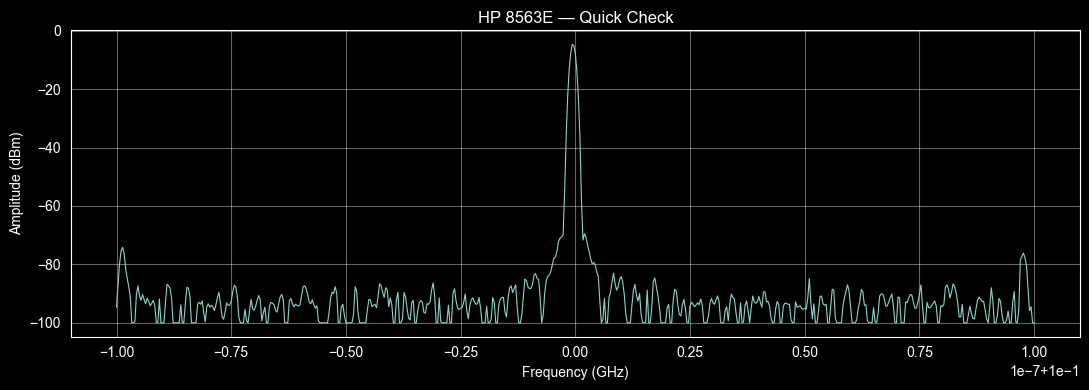

(array([9.99999000e+07, 9.99999003e+07, 9.99999007e+07, 9.99999010e+07,
        9.99999013e+07, 9.99999017e+07, 9.99999020e+07, 9.99999023e+07,
        9.99999027e+07, 9.99999030e+07, 9.99999033e+07, 9.99999037e+07,
        9.99999040e+07, 9.99999043e+07, 9.99999047e+07, 9.99999050e+07,
        9.99999053e+07, 9.99999057e+07, 9.99999060e+07, 9.99999063e+07,
        9.99999067e+07, 9.99999070e+07, 9.99999073e+07, 9.99999077e+07,
        9.99999080e+07, 9.99999083e+07, 9.99999087e+07, 9.99999090e+07,
        9.99999093e+07, 9.99999097e+07, 9.99999100e+07, 9.99999103e+07,
        9.99999107e+07, 9.99999110e+07, 9.99999113e+07, 9.99999117e+07,
        9.99999120e+07, 9.99999123e+07, 9.99999127e+07, 9.99999130e+07,
        9.99999133e+07, 9.99999137e+07, 9.99999140e+07, 9.99999143e+07,
        9.99999147e+07, 9.99999150e+07, 9.99999153e+07, 9.99999157e+07,
        9.99999160e+07, 9.99999163e+07, 9.99999167e+07, 9.99999170e+07,
        9.99999173e+07, 9.99999177e+07, 9.99999180e+07, 9.999991

In [15]:
# ── Example 1: Configure and plot ────────────────────────────────────────────
sa_configure()
sa_plot_trace(title="HP 8563E — Quick Check", save_png=True)

In [16]:
# ── Example 2: Find the peak and print its frequency / amplitude ──────────────
sa_configure()
sa_single_sweep()
freq, amp = sa_peak_search()
print(f"Peak is at {freq/1e9:.6f} GHz, {amp:.2f} dBm")

SA configured: CF=100.000 MHz, SP=0.000 MHz, RL=0.0 dBm, RBW=0.0 kHz, VBW=1000.0 kHz
SA single sweep complete.
Peak: 100.0000 MHz  →  -4.67 dBm
Peak is at 0.100000 GHz, -4.67 dBm


In [10]:
# ── Example 3: Save trace to CSV ─────────────────────────────────────────────
df = sa_save_trace()
display(df.head())

SA single sweep complete.
Fetched 601 points from TRA: 0.000 – 26500.000 MHz
Saved → ./data_sa\sa_trace_20260507_153848.csv


,frequency_hz,amplitude_dbm
0,0.000000e+00,-14.66
1,4.416667e+07,-86.83
2,8.833333e+07,-68.33
3,1.325000e+08,-88.50
4,1.766667e+08,-67.16


SA configured: CF=100.000 MHz, SP=0.000 MHz, RL=0.0 dBm, RBW=0.0 kHz, VBW=1000.0 kHz
SA trace TRA mode: MAXH
SA single sweep complete.
  Sweep 1/20
SA single sweep complete.
  Sweep 2/20
SA single sweep complete.
  Sweep 3/20
SA single sweep complete.
  Sweep 4/20
SA single sweep complete.
  Sweep 5/20
SA single sweep complete.
  Sweep 6/20
SA single sweep complete.
  Sweep 7/20
SA single sweep complete.
  Sweep 8/20
SA single sweep complete.
  Sweep 9/20
SA single sweep complete.
  Sweep 10/20
SA single sweep complete.
  Sweep 11/20
SA single sweep complete.
  Sweep 12/20
SA single sweep complete.
  Sweep 13/20
SA single sweep complete.
  Sweep 14/20
SA single sweep complete.
  Sweep 15/20
SA single sweep complete.
  Sweep 16/20
SA single sweep complete.
  Sweep 17/20
SA single sweep complete.
  Sweep 18/20
SA single sweep complete.
  Sweep 19/20
SA single sweep complete.
  Sweep 20/20
Fetched 601 points from TRA: 100.000 – 100.000 MHz


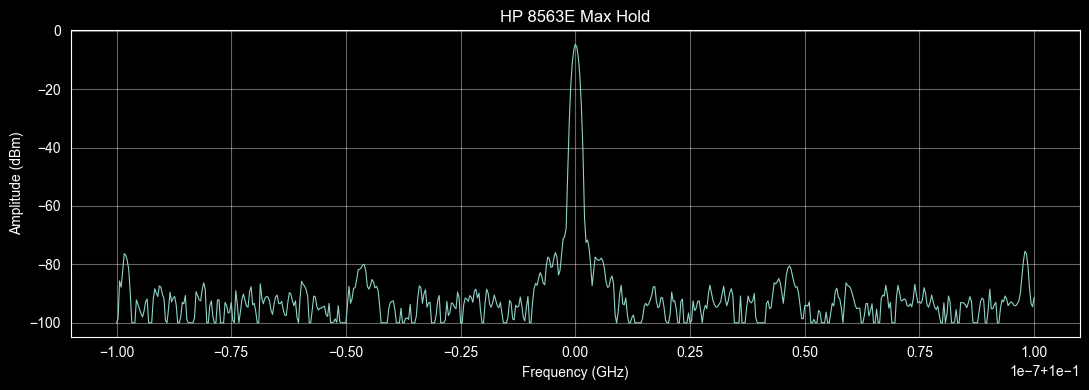

SA trace TRA mode: CLRW


In [17]:
# ── Example 4: Max-hold over 20 sweeps ───────────────────────────────────────
sa_configure()
sa_plot_max_hold(n_sweeps=20)

In [9]:
# ── Example 5: Query current settings ────────────────────────────────────────
settings = sa_query_settings()

  center_hz: 13250000000.0
  span_hz: 26500000000.0
  start_hz: 0.0
  stop_hz: 26500000000.0
  ref_dbm: 0.0
  rbw_hz: 1000000.0
  vbw_hz: 1000000.0


---
## 📡 Stitched Wide-Range Sweep

The HP 8563E always returns **601 points per sweep**, so wide spans get coarse resolution. To cover a wide range at fine resolution, this section tiles the range with N adjacent narrow sub-spans, sweeps each one, and concatenates the results into a single high-resolution spectrum.

**Specify one of:**
- `resolution_hz` — desired Hz/point (sub-span width = 600 × resolution)
- `total_points` — desired total points across the full range

When the requested range doesn't tile evenly, resolution is honored exactly and the final stop frequency may extend slightly past `stop_hz`.

Output: a single CSV (`frequency_hz`, `amplitude_dbm`, `sub_span_index`) and a single combined plot.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  STITCHED WIDE-RANGE SWEEP
# ══════════════════════════════════════════════════════════════════════════════

def sa_stitched_sweep(
    start_hz,
    stop_hz,
    resolution_hz=None,        # Hz between adjacent points (mutually exclusive with total_points)
    total_points=None,         # Desired total points across full range
    rbw_hz=None,               # If non-None, set RBW before sweeping
    vbw_hz=None,               # If non-None, set VBW before sweeping
    ref_dbm=None,              # If non-None, set reference level before sweeping
    atten_db=None,             # If non-None, set input attenuation before sweeping
    sweep_time_s=None,         # If non-None: 0 = AUTO, >0 = explicit seconds per sub-span
    trace=SA_TRACE,
    save_csv=True,
    save_png=False,
    filename_base=None,
    title=None,
    plot=True,
    settle_s=0.0,              # Extra seconds to wait after each sub-span config
    show_progress=True,
):
    """
    Tile a wide frequency range with adjacent narrow sub-spans, sweep each one,
    and concatenate the results into a single high-resolution spectrum.

    The HP 8563E returns exactly 601 points per sweep, so per-sub-span resolution
    is sub_span / 600. The number of sub-spans is derived from either
    `resolution_hz` or `total_points` — specify exactly one.

    Resolution is honored exactly: actual_stop_hz = start_hz + N * sub_span,
    which may extend slightly past the requested stop_hz.

    Parameters
    ----------
    start_hz, stop_hz : Overall sweep range (Hz).
    resolution_hz     : Desired Hz/point. Mutually exclusive with total_points.
    total_points      : Desired total points (≥ 601). Mutually exclusive with resolution_hz.
    rbw_hz, vbw_hz, ref_dbm, atten_db, sweep_time_s :
        If not None, applied before the first sub-span sweep. If None, current
        instrument settings are kept. RBW especially matters for a clean stitch —
        leave it explicit unless you know auto-RBW will be consistent.
    trace          : 'TRA', 'TRB', or 'TRC'.
    save_csv       : Save the combined CSV.
    save_png       : Save the combined plot as PNG.
    filename_base  : Base filename (timestamp appended). Auto-generated if None.
    title          : Plot title (auto-generated if None).
    plot           : If True, display the combined plot inline.
    settle_s       : Extra seconds to sleep after configuring each sub-span.
    show_progress  : Print one line per sub-span as it completes.

    Returns
    -------
    df : DataFrame with columns ['frequency_hz', 'amplitude_dbm', 'sub_span_index']
    """
    # ── 1) Validate spec ─────────────────────────────────────────────────────
    if (resolution_hz is None) == (total_points is None):
        raise ValueError("Specify exactly one of resolution_hz or total_points.")
    if stop_hz <= start_hz:
        raise ValueError("stop_hz must be > start_hz.")

    PTS_PER_SWEEP        = 601
    INTERVALS_PER_SWEEP  = PTS_PER_SWEEP - 1  # = 600
    total_range          = stop_hz - start_hz

    # ── 2) Resolve resolution_hz from total_points (if needed) ───────────────
    if total_points is not None:
        if total_points < PTS_PER_SWEEP:
            raise ValueError(f"total_points must be ≥ {PTS_PER_SWEEP} "
                             "(one sub-span yields 601 points).")
        resolution_hz = total_range / (total_points - 1)

    if resolution_hz <= 0:
        raise ValueError("resolution_hz must be > 0.")

    # ── 3) Compute sub-span width and N (resolution honored exactly) ─────────
    sub_span    = INTERVALS_PER_SWEEP * resolution_hz      # exact target span/sweep
    n_subspans  = max(1, int(np.ceil(total_range / sub_span)))
    actual_stop = start_hz + n_subspans * sub_span         # may exceed stop_hz
    actual_total_points = INTERVALS_PER_SWEEP * n_subspans + 1

    print("Stitched sweep plan:")
    print(f"  Requested range : {start_hz/1e6:.6f} – {stop_hz/1e6:.6f} MHz")
    print(f"  Actual range    : {start_hz/1e6:.6f} – {actual_stop/1e6:.6f} MHz "
          f"(Δ = {(actual_stop - stop_hz)/1e3:+.3f} kHz past stop)")
    print(f"  Resolution      : {resolution_hz:.3f} Hz/point "
          f"({resolution_hz/1e3:.3f} kHz)")
    print(f"  Sub-spans       : {n_subspans} × {sub_span/1e6:.6f} MHz each")
    print(f"  Total points    : {actual_total_points}")

    # ── 4) Apply optional per-sweep settings ─────────────────────────────────
    if ref_dbm is not None:
        sa.write(f'RL {ref_dbm:.1f} DM')
    if atten_db is not None:
        sa.write(f'AT {int(atten_db)} DB')
    if rbw_hz is not None:
        sa.write(f'RB {rbw_hz:.6e} HZ')
    if vbw_hz is not None:
        sa.write(f'VB {vbw_hz:.6e} HZ')
    if sweep_time_s is not None:
        if sweep_time_s > 0:
            sa.write(f'ST {sweep_time_s:.4f} SC')
        else:
            sa.write('ST AUTO')

    # ── 5) Sweep each sub-span and accumulate ────────────────────────────────
    all_freqs = []
    all_amps  = []
    all_segs  = []
    t0_total  = time.time()

    for i in range(n_subspans):
        sub_fa = start_hz + i * sub_span
        sub_fb = sub_fa + sub_span
        sa.write(f'FA {sub_fa:.6e} HZ')
        sa.write(f'FB {sub_fb:.6e} HZ')
        if settle_s > 0:
            time.sleep(settle_s)

        sa_single_sweep()
        freqs, amps = sa_fetch_trace(trace)

        # Drop the first sample of each sub-span after the first so adjacent
        # sub-spans don't double-count the shared boundary frequency.
        if i > 0:
            freqs = freqs[1:]
            amps  = amps[1:]

        all_freqs.append(freqs)
        all_amps.append(amps)
        all_segs.append(np.full(len(freqs), i, dtype=int))

        if show_progress:
            elapsed = time.time() - t0_total
            print(f"  [{i+1:3d}/{n_subspans}] "
                  f"{sub_fa/1e6:10.6f} – {sub_fb/1e6:10.6f} MHz  "
                  f"({len(amps)} new pts, {elapsed:6.1f} s elapsed)")

    freqs_full = np.concatenate(all_freqs)
    amps_full  = np.concatenate(all_amps)
    segs_full  = np.concatenate(all_segs)
    total_elapsed = time.time() - t0_total
    print(f"Stitched sweep complete: {len(freqs_full)} points in {total_elapsed:.1f} s.")

    # ── 6) DataFrame ─────────────────────────────────────────────────────────
    df = pd.DataFrame({
        'frequency_hz':   freqs_full,
        'amplitude_dbm':  amps_full,
        'sub_span_index': segs_full,
    })

    # ── 7) Save CSV ──────────────────────────────────────────────────────────
    ts = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
    if filename_base is None:
        filename_base = f'sa_stitched_{start_hz/1e6:.3f}MHz_to_{stop_hz/1e6:.3f}MHz'
    if save_csv:
        csv_path = os.path.join(OUTPUT_DIR, f'{filename_base}_{ts}.csv')
        df.to_csv(csv_path, index=False)
        print(f"Saved CSV → {csv_path}")

    # ── 8) Plot ──────────────────────────────────────────────────────────────
    if plot:
        # Pick x-axis units in powers of three based on range magnitude
        if actual_stop >= 1e9:
            x_data, x_label = freqs_full / 1e9, 'Frequency (GHz)'
        elif actual_stop >= 1e6:
            x_data, x_label = freqs_full / 1e6, 'Frequency (MHz)'
        else:
            x_data, x_label = freqs_full / 1e3, 'Frequency (kHz)'

        fig, ax = plt.subplots(figsize=(12, 4.5))
        ax.plot(x_data, amps_full, linewidth=0.7)
        ax.set_xlabel(x_label)
        ax.set_ylabel('Amplitude (dBm)')
        if title is None:
            title = (f'HP 8563E Stitched Sweep — '
                     f'{start_hz/1e6:.3f} to {actual_stop/1e6:.3f} MHz, '
                     f'{n_subspans} sub-spans, {resolution_hz/1e3:.3f} kHz/pt')
        ax.set_title(title)
        ax.grid(True, alpha=0.4)
        plt.tight_layout()
        if save_png:
            png_path = os.path.join(OUTPUT_DIR, f'{filename_base}_{ts}.png')
            plt.savefig(png_path, dpi=150)
            print(f"Saved PNG → {png_path}")
        plt.show()

    return df


print("sa_stitched_sweep() defined — ready for wide-range stitched sweeps.")


In [ ]:
# ── Example: Stitched sweep from 100 MHz to 1 GHz at 10 kHz resolution ───────
#   sub_span = 600 × 10 kHz = 6 MHz  →  N = ceil(900 / 6) = 150 sub-spans
#   actual_stop = 100 MHz + 150 × 6 MHz = 1000 MHz  (exact in this case)
df_stitched = sa_stitched_sweep(
    start_hz      = 100e6,
    stop_hz       = 1e9,
    resolution_hz = 10e3,     # 10 kHz/point
    rbw_hz        = 30e3,     # Set RBW explicitly for a clean stitch
    vbw_hz        = 30e3,
    ref_dbm       = 0,
    atten_db      = 'AUTO',
    save_csv      = True,
    save_png      = True,
)
display(df_stitched.head())


# ── Alternative spec: ~6000 total points instead of resolution ───────────────
# df_stitched = sa_stitched_sweep(
#     start_hz     = 100e6,
#     stop_hz      = 1e9,
#     total_points = 6000,
#     rbw_hz       = 30e3,
#     save_csv     = True,
# )


---
## 🔌 Cleanup

In [18]:
sa.write('*GTL')   # Return front-panel control to the operator
sa.close()
rm.close()
print("HP 8563E connection closed.")

HP 8563E connection closed.
